In [1]:
# Import necessary libraries for data processing and visualization
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import mlacca_functions as mlcf
from sklearn.utils.class_weight import compute_class_weight

import mlacca_functions as mlcf

In [2]:
# Define folder paths for input data and output files
data_folder = 'data\\csv_files\\molec_db'  # Molecular database CSV files

save_csvs_folder = 'data\\csv_files'  # Output location for processed CSV files
save_plots_folder = 'data\\plots\\van_krevelens'  # Output location for Van Krevelen plots

In [3]:
# Get list of all L&M (Laszakovits and MacKay) CSV files from the data folder
LM_files = [x for x in os.listdir(data_folder) if x.endswith('.csv') and 'l&m' in x]

In [4]:
# Functions

def get_elements_from_formula(formula) -> dict:
    """
    Parse a molecular formula string and extract element counts.
    
    Args:
        formula (str): Molecular formula (e.g., 'C6H12O6')
    
    Returns:
        dict: Dictionary mapping element symbols to their counts
              (e.g., {'C': 6, 'H': 12, 'O': 6})
    """
    elements = {}
    current_element = ''
    current_count = ''
    
    for char in formula:
        if char.isupper():
            # Save previous element if exists
            if current_element:
                elements[current_element] = int(current_count) if current_count else 1
            current_element = char
            current_count = ''
        elif char.islower():
            # Add to current element (e.g., 'C' + 'l' = 'Cl')
            current_element += char
        elif char.isdigit():
            # Build the count number
            current_count += char
    
    # Add the last element
    if current_element:
        elements[current_element] = int(current_count) if current_count else 1
    
    return elements


def get_peptide_formula(sequence, amino_acids_dict) -> dict:
    """
    Calculate the total elemental composition of a peptide from its sequence.
    
    Args:
        sequence (str): Peptide sequence using single-letter amino acid codes (e.g., 'ACDEFG')
        amino_acids_dict (dict): Dictionary mapping amino acid codes to their elemental compositions
    
    Returns:
        dict: Total elemental composition of the peptide
              (e.g., {'C': 24, 'H': 40, 'O': 8, 'N': 6})
    """
    total_elements = {}
    
    # Sum up elements from each amino acid in the sequence
    for aa in sequence:
        aa_elements = amino_acids_dict.get(aa, {})
        for element, count in aa_elements.items():
            total_elements[element] = total_elements.get(element, 0) + count
    
    return total_elements


def annotate_aa_plot(text, df, ax, xytext):
    """
    Add an annotation with an arrow to a matplotlib axis for amino acid plots.
    
    Args:
        text (str): Label text (amino acid name)
        df (pd.DataFrame): DataFrame containing O/C and H/C ratios, indexed by amino acid names
        ax (matplotlib.axes.Axes): Matplotlib axis object to add annotation to
        xytext (tuple): (x, y) coordinates for the text label position
    """
    ax.annotate(text, fontsize=14,
                xy=(df.loc[text]['O/C'], df.loc[text]['H/C']),
                xytext=xytext, arrowprops=dict(arrowstyle="-"),
                horizontalalignment='center', verticalalignment='bottom')


In [5]:
# Process L&M (Lipids & Metabolites) Files
# Build a comprehensive dataframe with elemental compositions and ratios

overall_df = pd.DataFrame()
amino_acids_dict = {}  # Store amino acid elemental compositions for peptide calculations

for file in LM_files:
    file_path = os.path.join(data_folder, file)
    df = pd.read_csv(file_path)

    # Extract category name from filename
    category = file.replace('.csv', '').replace('l&m-', '')

    # Special handling for amino acids - store their compositions for peptide calculations
    if category == 'amino_acid':
        for letter in df['1-letter code']:
            amino_acids_dict[letter] = get_elements_from_formula(df['FORMULA'][df['1-letter code'] == letter].to_list()[0])
        
        # Amino acids will be grouped under 'peptide' category
        category = 'peptide'
    
    # Initialize dataframe slice for this category
    df_slice = pd.DataFrame({'category': [category] * len(df)})
    atomic_dict = {'C': [], 'H': [], 'O': [], 'N': [], 'S': [], 'P': []}

    try:
        # Try to get formula directly from the dataframe
        df_slice['formula'] = df['FORMULA']

    except KeyError:
        # Handle special cases where formula needs to be calculated
        if category == 'peptide':
            # Calculate formulas from peptide sequences
            seqs = df['Sequence'].to_list()
            peptides_formula_dict_list = [get_peptide_formula(seq, amino_acids_dict) for seq in seqs]

            df_slice['formula'] = [''.join([f'{x}{formula_dict[x]}' for x in formula_dict]) for formula_dict in peptides_formula_dict_list]

        elif category == 'lignin':
            # Lignin data has individual element columns instead of formulas
            for element in atomic_dict.keys():
                if element in df.columns:
                    atomic_dict[element] = df[element].to_list()
                else:
                    atomic_dict[element] = [0] * len(df)
    
    # Parse formulas into individual element counts (skip for lignin as already done)
    if category != 'lignin':
        for formula in df_slice['formula']:
            elements = get_elements_from_formula(formula)
            for element in atomic_dict.keys():
                atomic_dict[element].append(elements.get(element, 0))
    
    # Convert atomic counts to dataframe and combine with category info
    atomic_df = pd.DataFrame(atomic_dict)
    df_slice = pd.concat([df_slice, atomic_df], axis=1)

    if category == 'peptide':
        # Add water to peptide formulas
        df_slice['H'] += 2
        df_slice['O'] += 1
    
    # Append to overall dataframe
    if len(overall_df) == 0:
        overall_df = df_slice
    else:
        overall_df = pd.concat([overall_df, df_slice], ignore_index=True)

# Calculate elemental ratios (normalized to carbon)
for element in atomic_dict.keys():
    if element != 'C':
        overall_df[f'{element}/C'] = overall_df[element] / overall_df['C']

# Calculate N/P ratio (important for nutrient analysis)
overall_df['N/P'] = overall_df['N'] / overall_df['P']

In [6]:
# Display category distribution and sort the dataframe
print(overall_df['category'].value_counts())

# Sort by category for better organization
overall_df = overall_df.sort_values(by=['category']).reset_index(drop=True)

category
lipid           5109
lignin           297
peptide          263
tannin           192
carbohydrate      79
amino_sugar       51
Name: count, dtype: int64


In [7]:
# Compute class weights to handle imbalanced dataset
# This gives higher weight to underrepresented categories during model training

class_weights = compute_class_weight('balanced', classes=np.unique(overall_df['category']), y=overall_df['category'])
weights_dict = {cls: weight for cls, weight in zip(np.unique(overall_df['category']), class_weights)}

# Add weights column to dataframe
overall_df['weights'] = [weights_dict[cat] for cat in overall_df['category']]

In [8]:
# Save the processed dataframe (without PAHs)
overall_df.to_csv(f'{save_csvs_folder}\\new_vk_areas_df.csv', index=False)

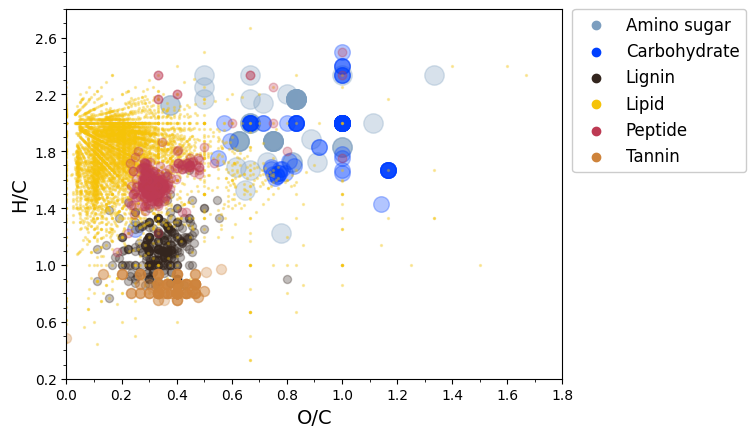

In [9]:
# Create Van Krevelen Diagram
# Van Krevelen diagrams show O/C vs H/C ratios to visualize molecular composition

fig, ax = plt.subplots()

# Plot each category with different colors
# Point size is inversely proportional to category size (more visible for smaller categories)
for category in overall_df['category'].unique():
    subset = overall_df[overall_df['category'] == category]
    ax.scatter(subset['O/C'], subset['H/C'],
               c=mlcf.vk_region_colours[category],
               alpha=0.3, s=1e4/len(overall_df[overall_df['category'] == category]))

# Create legend with proper labels
for cat in overall_df['category'].unique():
    ax.scatter(None, None, c=mlcf.vk_region_colours[cat],
               label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH')

# Set axis labels and formatting
ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)

mlcf.set_axis_ticks(overall_df['O/C'].values, ax, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
mlcf.set_axis_ticks(overall_df['H/C'].values, ax, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)

ax.legend(framealpha=1, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=12)
fig.savefig(f'{save_plots_folder}\\vk_diagram.svg', dpi=600, facecolor='#fff', bbox_inches='tight')


{'O/C': [0.8333333333333334,
  0.75,
  0.75,
  0.8333333333333334,
  0.8333333333333334,
  0.8333333333333334,
  0.8333333333333334,
  0.75,
  0.8,
  0.375,
  0.8333333333333334,
  0.8333333333333334,
  0.8333333333333334,
  0.5,
  0.7142857142857143,
  0.375,
  1.3333333333333333,
  0.75,
  0.75,
  0.6666666666666666,
  0.6666666666666666,
  0.6666666666666666,
  0.6153846153846154,
  0.7272727272727273,
  0.5,
  0.75,
  0.9090909090909091,
  0.625,
  0.625,
  0.625,
  0.625,
  0.625,
  0.75,
  0.8181818181818182,
  0.7777777777777778,
  1.1111111111111112,
  0.8333333333333334,
  0.75,
  0.8333333333333334,
  0.8333333333333334,
  0.8181818181818182,
  0.6666666666666666,
  0.6470588235294118,
  0.5,
  0.6666666666666666,
  1.0,
  1.0,
  1.0,
  1.0,
  0.6666666666666666,
  0.8888888888888888,
  1.0,
  0.8333333333333334,
  1.0,
  1.0,
  1.1666666666666667,
  1.0,
  1.0,
  1.1666666666666667,
  0.8333333333333334,
  1.0,
  0.8333333333333334,
  0.6666666666666666,
  0.8333333333333334

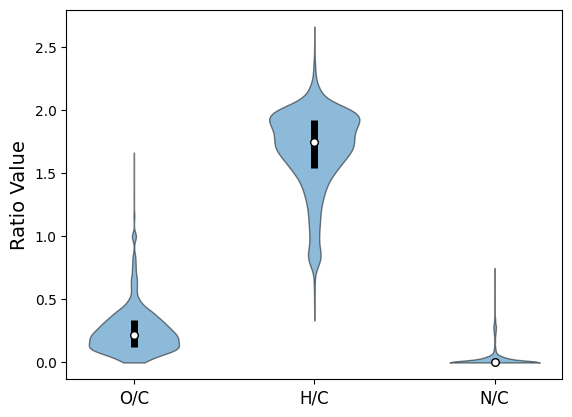

In [36]:
fig, ax = plt.subplots()

violin_plot_labels = ['O/C','H/C','N/C']
violin_plot_data = [overall_df[x].tolist() for x in violin_plot_labels]

parts = ax.violinplot(violin_plot_data,
                      showmeans=False, showmedians=False,
                      showextrema=False)
for pc in parts['bodies']:
    pc.set_edgecolor('black')
    pc.set_alpha(.5)
quartile1, medians, quartile3 = np.percentile(np.array(violin_plot_data), [25, 50, 75], axis=1)

inds = np.arange(1, len(medians) + 1)
ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3, edgecolors='k')
ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)

ax.set_ylabel('Ratio Value', fontsize=14)
ax.set_xticks(np.arange(1, len(violin_plot_labels) + 1), violin_plot_labels, fontsize=12)


In [10]:
# Create Amino Acid Reference Table
# Convert single-letter amino acid codes to 3-letter codes

code_cipher = {
    'A': 'Ala',
    'R': 'Arg',
    'N': 'Asn',
    'D': 'Asp',
    'C': 'Cys',
    'Q': 'Gln',
    'E': 'Glu',
    'G': 'Gly',
    'H': 'His',
    'I': 'Ile',
    'L': 'Leu',
    'K': 'Lys',
    'M': 'Met',
    'F': 'Phe',
    'P': 'Pro',
    'S': 'Ser',
    'T': 'Thr',
    'W': 'Trp',
    'Y': 'Tyr',
    'V': 'Val',
}

# Convert amino acid dictionary to use 3-letter codes
amino_acids_dict_3lett = {code_cipher[aa]: amino_acids_dict[aa] for aa in amino_acids_dict}
aa_df = pd.DataFrame(amino_acids_dict_3lett).T

aa_df['H'] += 2
aa_df['O'] += 1

# Calculate elemental ratios for each amino acid
dims = ['O/C', 'H/C', 'N/C']
for d in dims:
    aa_df[d] = aa_df[d[0]] / aa_df['C']

aa_df

,C,H,O,N,S,O/C,H/C,N/C
Ala,3.0,7.0,2.0,1.0,NaN,0.666667,2.333333,0.333333
Arg,6.0,14.0,2.0,4.0,NaN,0.333333,2.333333,0.666667
Asn,4.0,8.0,3.0,2.0,NaN,0.750000,2.000000,0.500000
Asp,4.0,7.0,4.0,1.0,NaN,1.000000,1.750000,0.250000
Cys,3.0,7.0,2.0,1.0,1.0,0.666667,2.333333,0.333333
Glu,5.0,9.0,4.0,1.0,NaN,0.800000,1.800000,0.200000
Gln,5.0,10.0,3.0,2.0,NaN,0.600000,2.000000,0.400000
Gly,2.0,5.0,2.0,1.0,NaN,1.000000,2.500000,0.500000
His,6.0,9.0,2.0,3.0,NaN,0.333333,1.500000,0.500000
Ile,6.0,13.0,2.0,1.0,NaN,0.333333,2.166667,0.166667


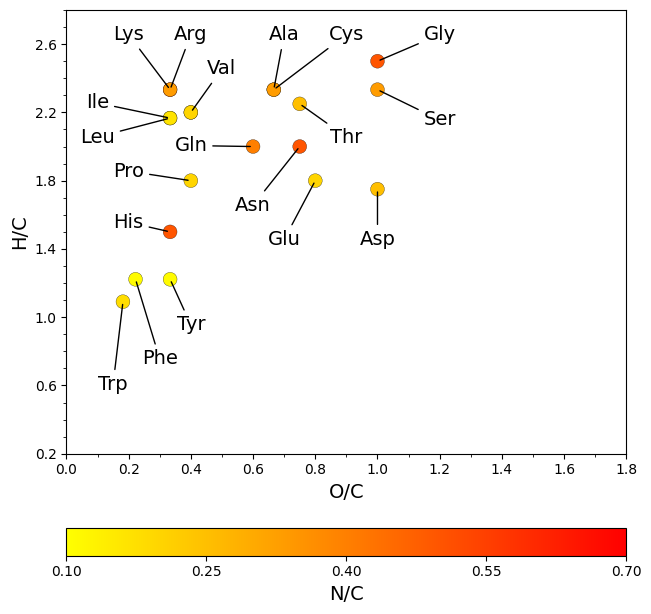

In [11]:
# Plot Amino Acids on Van Krevelen Diagram with N/C Color Coding

fig, ax = plt.subplots(figsize=(6.4, 6), layout='constrained')

# Set up color normalization for N/C ratio
norm_lims = (np.round(aa_df['N/C'].min(), 1), np.round(aa_df['N/C'].max(), 1))
norm = mpl.colors.Normalize(vmin=norm_lims[0], vmax=norm_lims[1])

# Plot amino acids with N/C ratio represented by color
ax_plot = ax.scatter(aa_df['O/C'], aa_df['H/C'], s=100,
                     norm=norm, c=aa_df['N/C'], cmap='autumn_r', edgecolors='k', lw=.2)

# Annotate each amino acid with its 3-letter code
# Positions manually adjusted for clarity and to avoid overlap
for combo in [['Lys', (.2, 2.6)],
              ['Arg', (.4, 2.6)],
              ['Ile', (.1, 2.2)],
              ['Leu', (.1, 2)],
              ['Val', (.5, 2.4)],
              ['Cys', (.9, 2.6)],
              ['Ala', (.7, 2.6)],
              ['Thr', (.9, 2)],
              ['Ser', (1.2, 2.1)],
              ['Gln', (.4, 1.95)],
              ['Gly', (1.2, 2.6)],
              ['Asn', (.6, 1.6)],
              ['Glu', (.7, 1.4)],
              ['Asp', (1, 1.4)],
              ['Pro', (.2, 1.8)],
              ['His', (.2, 1.5)],
              ['Tyr', (.4, .9)],
              ['Phe', (.3, .7)],
              ['Trp', (.15, .55)],
              ]:
    annotate_aa_plot(combo[0], aa_df, ax, (combo[1]))

# Format axes
mlcf.set_axis_ticks(overall_df['O/C'].values, ax, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
mlcf.set_axis_ticks(overall_df['H/C'].values, ax, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)
ax.set_xlabel('O/C', fontsize=14)
ax.set_ylabel('H/C', fontsize=14)

# Add colorbar for N/C ratio
cbar = fig.colorbar(ax_plot, ticks=np.linspace(norm_lims[0], norm_lims[1], 5), location='bottom')
cbar.set_label(label='N/C', size=14)

fig.savefig(f'{save_plots_folder}\\amino_acids.svg', dpi=600, facecolor='#fff', bbox_inches='tight')

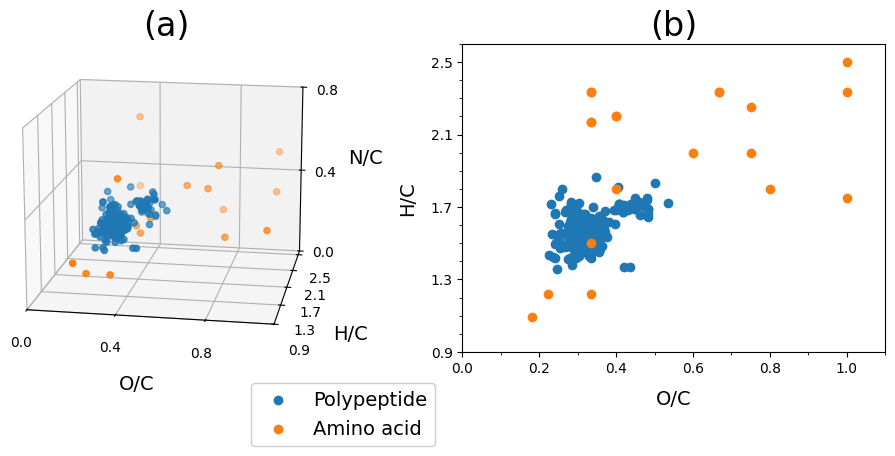

In [12]:
# Compare Amino Acids vs Polypeptides in 3D and 2D

# Create polypeptide dataframe from previously calculated formula list
pept_df = pd.DataFrame(peptides_formula_dict_list)
pept_df['H'] += 2
pept_df['O'] += 1
for d in dims:
    pept_df[d] = pept_df[d[0]] / pept_df['C']

fig = plt.figure(figsize=(12, 4))

# Add type labels for legend
aa_df['type'] = ['Amino acid'] * len(aa_df)
pept_df['type'] = ['Polypeptide'] * len(pept_df)

concat_df = pd.concat((aa_df, pept_df))

label_dict = {'Polypeptide': 'tab:blue', 'Amino acid': 'tab:orange'}

# 3D Plot (subplot a)
ax1 = fig.add_subplot(121, projection='3d')

ax1.scatter(concat_df['O/C'], concat_df['H/C'], concat_df['N/C'],
            c=[label_dict[x] for x in concat_df['type']])

# Format 3D axes
mlcf.set_axis_ticks(concat_df['O/C'], ax1, axis='x', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1)
mlcf.set_axis_ticks(concat_df['H/C'], ax1, axis='y', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1)
mlcf.set_axis_ticks(concat_df['N/C'], ax1, axis='z', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1)

ax1.set_xlabel('O/C', fontsize=14, labelpad=8)
ax1.set_ylabel('H/C', fontsize=14, labelpad=10)
ax1.set_zlabel('N/C', fontsize=14, labelpad=10)

ax1.view_init(elev=15, azim=-80)
ax1.set_box_aspect(None, zoom=1.2)
ax1.set_title('(a)', fontsize=24)

# 2D Plot (subplot b)
ax2 = fig.add_subplot(122)

for t in ['Polypeptide', 'Amino acid']:
    ax2.scatter(concat_df[concat_df['type']==t]['O/C'], concat_df[concat_df['type']==t]['H/C'],
                label=t, c=label_dict[t])

# Format 2D axes
mlcf.set_axis_ticks(concat_df['O/C'].values, ax2, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
mlcf.set_axis_ticks(concat_df['H/C'].values, ax2, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)

ax2.set_xlabel('O/C', fontsize=14, labelpad=10)
ax2.set_ylabel('H/C', fontsize=14, labelpad=10)

ax2.legend(framealpha=1, bbox_to_anchor=(-.5, -.1), loc='upper left', borderaxespad=0, fontsize=14)
ax2.set_title('(b)', fontsize=24)

fig.savefig(f'{save_plots_folder}\\amino_acids_&_peptides.svg', dpi=600, facecolor='#fff', bbox_inches='tight')

# Create a CSV file to include PAHs as well 

In [13]:
# Get all remaining CSV files (including PAHs) that weren't in the L&M set
all_files = [x for x in os.listdir(data_folder) if x.endswith('.csv') and x not in LM_files]

In [14]:
# Process All Files Including PAHs
# Create an extended dataset that includes Polycyclic Aromatic Hydrocarbons (PAHs)

overall_df_with_pahs = pd.DataFrame()

for file in all_files:
    df = pd.read_csv(os.path.join(data_folder, file))

    category = file.replace('.csv', '')

    atomic_dict = {'C': [], 'H': [], 'O': [], 'N': [], 'S': [], 'P': []}

    # Create category dataframe slice
    df_slice = pd.DataFrame({'category': [category] * len(df)})
    df_slice['formula'] = df['FORMULA']

    # Parse formulas and extract elemental counts
    for formula in df_slice['formula']:
        elements = get_elements_from_formula(formula)

        for element in atomic_dict.keys():
            atomic_dict[element].append(elements.get(element, 0))

    # Add atomic counts to dataframe
    atomic_df = pd.DataFrame(atomic_dict)
    df_slice = pd.concat([df_slice, atomic_df], axis=1)

    # Calculate elemental ratios (normalized to carbon)
    for element in atomic_dict.keys():
        if element != 'C':
            df_slice[f'{element}/C'] = df_slice[element] / df_slice['C']
    
    # Combine with main dataframe
    overall_df_with_pahs = pd.concat([overall_df, df_slice], ignore_index=True) if len(overall_df_with_pahs) == 0 else pd.concat([overall_df_with_pahs, df_slice], ignore_index=True)

# Calculate N/P ratio
overall_df_with_pahs['N/P'] = overall_df_with_pahs['N'] / overall_df_with_pahs['P']

# Display category distribution
print(overall_df_with_pahs['category'].value_counts())

# Sort by category
overall_df_with_pahs = overall_df_with_pahs.sort_values(by=['category']).reset_index(drop=True)

category
lipid           5109
lignin           297
peptide          263
tannin           192
pah               86
carbohydrate      79
amino_sugar       51
Name: count, dtype: int64


In [15]:
# Compute class weights for the extended dataset (with PAHs)
# This ensures balanced learning across all categories including PAHs

class_weights = compute_class_weight('balanced', classes=np.unique(overall_df_with_pahs['category']), y=overall_df_with_pahs['category'])
weights_dict_with_pahs = {cls: weight for cls, weight in zip(np.unique(overall_df_with_pahs['category']), class_weights)}

overall_df_with_pahs['weights'] = [weights_dict_with_pahs[cat] for cat in overall_df_with_pahs['category']]

# Save the extended dataset
overall_df_with_pahs.to_csv(f'{save_csvs_folder}\\new_vk_areas_with_pahs.csv', index=False)

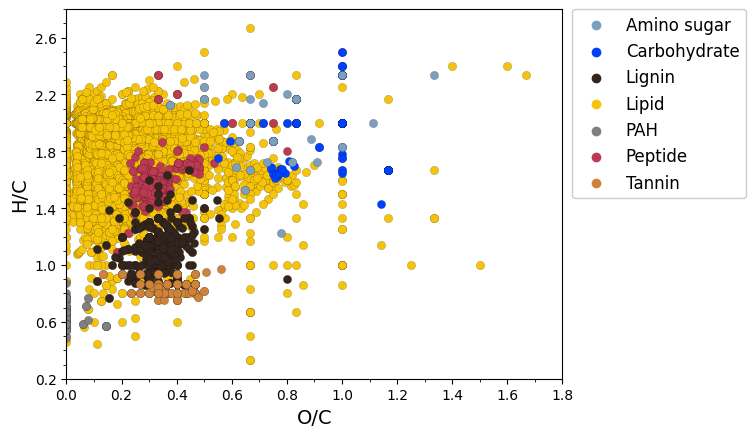

In [16]:
# Create Van Krevelen Diagram with PAHs (2D)

fig, ax_2d = plt.subplots()

# Plot each category with distinct colors
for category in ['lipid', 'peptide', 'carbohydrate', 'amino_sugar', 'lignin', 'tannin', 'pah']:
    subset = overall_df_with_pahs[overall_df_with_pahs['category'] == category]
    ax_2d.scatter(subset['O/C'], subset['H/C'],
                  c=mlcf.vk_region_colours[category],
                  edgecolor='k', lw=.1)
    
# Create legend
for cat in overall_df_with_pahs['category'].unique():
    ax_2d.scatter(None, None, c=mlcf.vk_region_colours[cat],
                  label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH')

# Format axes
ax_2d.set_xlabel('O/C', fontsize=14)
ax_2d.set_ylabel('H/C', fontsize=14)

mlcf.set_axis_ticks(overall_df_with_pahs['O/C'].values, ax_2d, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
mlcf.set_axis_ticks(overall_df_with_pahs['H/C'].values, ax_2d, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)

ax_2d.legend(framealpha=1, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=12)
fig.savefig(f'{save_plots_folder}\\vk_diagram_with_pahs.svg', dpi=600, facecolor='#fff', bbox_inches='tight')

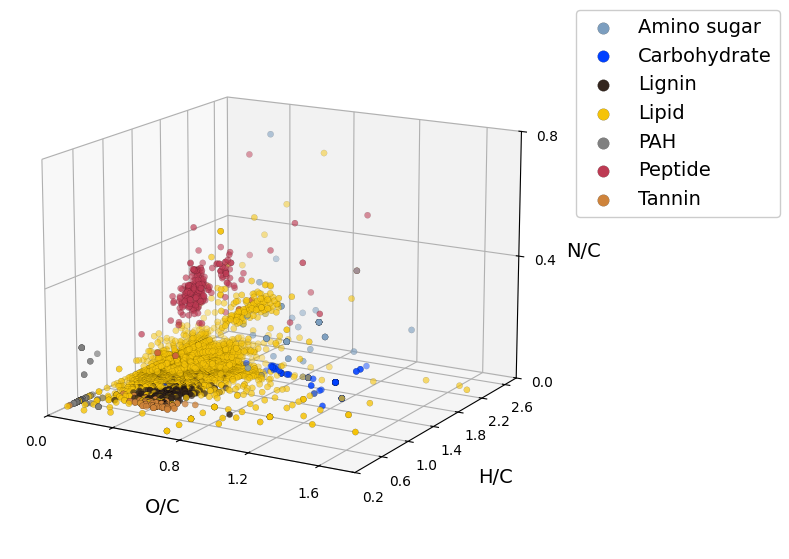

In [17]:
# Create 3D Van Krevelen Diagram with PAHs
# Third dimension (N/C) provides additional chemical space information

fig = plt.figure(figsize=(12, 7))  # width, height

ax_3d = fig.add_subplot(111, projection='3d')

# Plot all data points colored by category
ax_3d.scatter(overall_df_with_pahs['O/C'], overall_df_with_pahs['H/C'], overall_df_with_pahs['N/C'],
              c=[mlcf.vk_region_colours[cat] for cat in overall_df_with_pahs['category']],
              edgecolor='k', lw=.1)

# Set axis ranges and ticks
mlcf.set_axis_ticks(overall_df_with_pahs['O/C'], ax_3d, axis='x', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, 1.8), upper_lim=max(0, 1.8))
mlcf.set_axis_ticks(overall_df_with_pahs['H/C'], ax_3d, axis='y', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(.2, 2.8), upper_lim=max(.2, 2.8))
mlcf.set_axis_ticks(overall_df_with_pahs['N/C'], ax_3d, axis='z', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, .8), upper_lim=max(0, .8))

# Create legend (plotted outside visible range so only labels show)
for cat in overall_df_with_pahs['category'].unique():
    ax_3d.scatter(10, 10, 10, c=mlcf.vk_region_colours[cat], alpha=1, edgecolor='k', lw=.1,
                  label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH',
                  s=70)
    
ax_3d.legend(framealpha=1, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=14)
ax_3d.view_init(elev=15, azim=-60)

# Label axes
ax_3d.set_xlabel('O/C', fontsize=14, labelpad=15)
ax_3d.set_ylabel('H/C', fontsize=14, labelpad=15)
ax_3d.set_zlabel('N/C', fontsize=14, labelpad=8)

fig.savefig(f'{save_plots_folder}\\vk_diagram_with_pahs_3d.svg', dpi=600, facecolor='#fff', bbox_inches='tight')

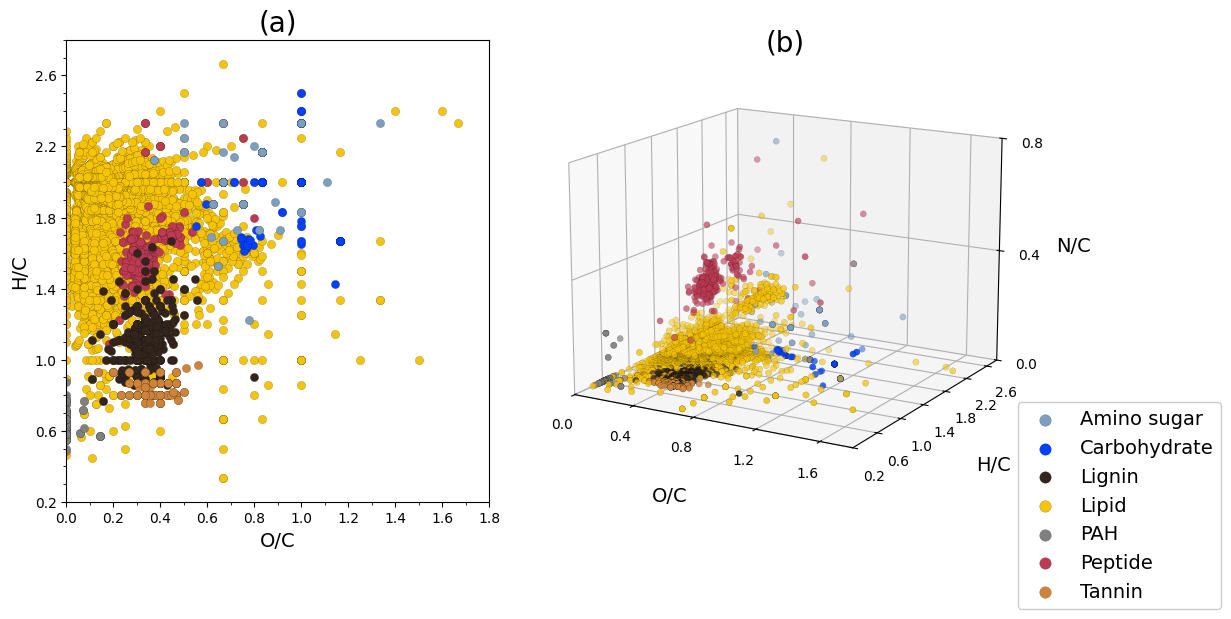

In [18]:
# Create Combined 2D and 3D Van Krevelen Diagram with PAHs
# Side-by-side comparison showing both perspectives

fig = plt.figure(figsize=(12, 6))

# 2D Plot (subplot a)
ax_2d = fig.add_subplot(121)

for category in ['lipid', 'peptide', 'carbohydrate', 'amino_sugar', 'lignin', 'tannin', 'pah']:
    subset = overall_df_with_pahs[overall_df_with_pahs['category'] == category]
    ax_2d.scatter(subset['O/C'], subset['H/C'],
                  c=mlcf.vk_region_colours[category],
                  edgecolor='k', lw=.1)

ax_2d.set_xlabel('O/C', fontsize=14)
ax_2d.set_ylabel('H/C', fontsize=14)

mlcf.set_axis_ticks(overall_df_with_pahs['O/C'].values, ax_2d, axis='x', major_ticks_interval=.2, minor_ticks_interval=.1, rounding=1, lower_lim=0)
mlcf.set_axis_ticks(overall_df_with_pahs['H/C'].values, ax_2d, axis='y', major_ticks_interval=.4, minor_ticks_interval=.1, rounding=1)

# 3D Plot (subplot b)
ax_3d = fig.add_subplot(122, projection='3d')

ax_3d.scatter(overall_df_with_pahs['O/C'], overall_df_with_pahs['H/C'], overall_df_with_pahs['N/C'],
              c=[mlcf.vk_region_colours[cat] for cat in overall_df_with_pahs['category']],
              edgecolor='k', lw=.1)

mlcf.set_axis_ticks(overall_df_with_pahs['O/C'], ax_3d, axis='x', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, 1.8), upper_lim=max(0, 1.8))
mlcf.set_axis_ticks(overall_df_with_pahs['H/C'], ax_3d, axis='y', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(.2, 2.8), upper_lim=max(.2, 2.8))
mlcf.set_axis_ticks(overall_df_with_pahs['N/C'], ax_3d, axis='z', major_ticks_interval=.4, minor_ticks_interval=None, rounding=1, lower_lim=min(0, .8), upper_lim=max(0, .8))

# Create legend (shared between both plots)
for cat in overall_df_with_pahs['category'].unique():
    ax_3d.scatter(10, 10, 10, c=mlcf.vk_region_colours[cat], alpha=1, edgecolor='k', lw=.1,
                  label=cat.replace('_', ' ').capitalize() if cat != 'pah' else 'PAH',
                  s=70)
    
ax_3d.legend(framealpha=1, bbox_to_anchor=(1.05, -0.3), loc='lower left', borderaxespad=0, fontsize=14)
ax_3d.view_init(elev=15, azim=-60)

ax_3d.set_xlabel('O/C', fontsize=14, labelpad=15)
ax_3d.set_ylabel('H/C', fontsize=14, labelpad=15)
ax_3d.set_zlabel('N/C', fontsize=14, labelpad=8)

ax_3d.set_box_aspect(None, zoom=1.15)

# Add subplot labels
ax_2d.set_title('(a)', fontsize=20)
ax_3d.set_title('(b)', fontsize=20)

fig.savefig(f'{save_plots_folder}\\vk_diagram_with_pahs_2d_&_3d.svg', dpi=600, facecolor='#fff', bbox_inches='tight')